# Intent & Topic Classifier (Model 3) — **Approach B: Augmented Minority**
**Project:** SRH AI Platform — ALU Capstone (Rwandan Youth & PWDs)
**Input:** `data/Topic_Classifier_data/topic_{train,val,test}.csv` + an in-notebook authored bank
**Output:** `models/topic_classifier_B.pkl` + comparison chart + confusion matrix

## Two-notebook experiment (read this)
Same dataset and pipeline as Approach A, with **one change**: the two scarce classes
`gbv_consent` (~44 real rows) and `disability_srh` (~50 real rows) are **bolstered with
a hand-authored question bank** (~220 each), generated in-notebook from templates with
realistic Rwanda/SRH variety. This is the **same `predefined` pattern the safety
classifier (Model 1) already uses** to cover under-represented SRH intents.

| | **A** | **B (this notebook)** |
|---|---|---|
| Rare-class data | ~44 / ~50 real rows | ~220 each (real + authored) |
| Pro | Honest; no synthetic data | Rare classes **usable**; better GBV/disability recall |
| Con | Rare classes score poorly | Rare-class val/test metrics are **optimistic** (templated text is easy) |

**Important evaluation caveat:** because the authored rows are split across train/val/**test**,
the reported `gbv_consent` / `disability_srh` test F1 is **optimistic** — it partly measures
performance on clean templated questions, not messy real ones. Approach A is the honest
evaluation; Approach B shows what a **deployable** model could look like once real GBV /
disability data is collected. The authored data is disclosed in the saved metadata
(`source='authored_bank'`). Train-from-scratch: TF-IDF + LR / Linear SVM / XGBoost.

---
## STEP 0 — Install dependencies

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib
print('Dependencies ready.')

Dependencies ready.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## STEP 1 — Imports and config

In [2]:
APPROACH = 'Approach B — Augmented Minority'
TAG = 'B'
import os, json, time, warnings, joblib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CANDIDATES = [
    'data/Topic_Classifier_data', '../data/Topic_Classifier_data',
    'srh-ml-model/data/Topic_Classifier_data', '.',
]
DATA_DIR = next((p for p in CANDIDATES
                 if os.path.exists(os.path.join(p, 'topic_train.csv'))), None)
assert DATA_DIR is not None, 'Could not find topic_train.csv — set DATA_DIR manually.'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Data directory : {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')

Data directory : data/Topic_Classifier_data
Model directory: models


---
## STEP 2 — Load data **+ authored minority bank**
Loads the three real splits, then generates a hand-authored question bank for the two
scarce classes and appends it (stratified 70/15/15). All authored rows are tagged
`source='authored_bank'` so they are traceable and disclosed.

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'topic_train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'topic_val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'topic_test.csv'))
with open(os.path.join(DATA_DIR, 'topic_label_map.json')) as f:
    LABEL_MAP = json.load(f)
TOPIC_TO_INT = {k: int(v) for k, v in LABEL_MAP['topic_to_int'].items()}
INT_TO_TOPIC = {int(k): v for k, v in LABEL_MAP['int_to_topic'].items()}
CLASS_NAMES  = [INT_TO_TOPIC[i] for i in range(len(INT_TO_TOPIC))]
for df in (train_df, val_df, test_df):
    df['text'] = df['text'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)
print('Base split sizes:  '
      f'train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')

# ── Hand-authored question bank for the two scarce classes ───────────────────
# Same idea as the safety notebook\'s PREDEFINED bank, scaled up. Templated
# combinations give realistic variety; every row contains its class\'s keywords so
# the label is unambiguous. Source tag = \'authored_bank\' (disclosed as synthetic).
import itertools

PLACES = ['Rwanda', 'Kigali', 'my district', 'my health centre', 'my community',
          'an Isange One Stop Centre', 'my village']

# gbv_consent ----------------------------------------------------------------
GBV_VIOLENCE = ['sexual violence', 'rape', 'sexual assault', 'gender-based violence',
                'domestic violence', 'intimate partner violence', 'sexual abuse',
                'sexual harassment', 'forced sex', 'sexual coercion', 'marital rape',
                'defilement']
GBV_SITUATION = ['someone touches me without my consent',
                 'my partner forces me to have sex',
                 'someone is pressuring me into sex',
                 'a relative sexually abused me', 'my husband beats me',
                 'a teacher is sexually harassing me',
                 'someone threatens me unless I have sex with them',
                 'I was raped by someone I know']
GBV_RIGHT = ['say no to sex even if I said yes before',
             'refuse to have sex with my husband',
             'withdraw my consent during sex',
             'report my partner for sexual assault',
             'press charges after a rape']
gbv = []
for v in GBV_VIOLENCE:
    for p in PLACES:
        gbv.append(f'Where can I report {v} in {p}?')
        gbv.append(f'What support is available for survivors of {v} in {p}?')
    gbv.append(f'What should I do if I experience {v}?')
    gbv.append(f'Is {v} a crime that I can report to the police?')
for s in GBV_SITUATION:
    gbv.append(f'What should I do if {s}?')
    gbv.append(f'Who can help me if {s}?')
for r in GBV_RIGHT:
    gbv.append(f'Can I {r}?')
gbv += [
    'What does sexual consent mean in a relationship?',
    'What is the difference between consent and coercion?',
    'Can someone give consent to sex if they are drunk?',
    'Is it still rape if it happens inside a marriage?',
    'What are the signs of an abusive relationship?',
    'How do I support a friend who has been sexually assaulted?',
]

# disability_srh -------------------------------------------------------------
DISABILITY = ['visual impairment', 'hearing impairment', 'physical disability',
              'intellectual disability', 'mobility impairment', 'low vision',
              'cerebral palsy', 'a wheelchair user', 'blindness', 'deafness']
SRH_SERVICE = ['SRH services', 'HIV testing', 'contraception services',
               'antenatal care', 'family planning services', 'STI testing',
               'maternity care', 'menstrual health support']
FORMATS = ['braille', 'sign language', 'audio format', 'easy-read format', 'large print']
SRH_INFO = ['contraception information', 'HIV prevention information',
            'pregnancy information', 'menstrual hygiene information',
            'sexual health information']
SRH_METHOD = ['contraception', 'condoms', 'the contraceptive implant',
              'family planning methods', 'an IUD']
dis = []
for d in DISABILITY:
    for srv in SRH_SERVICE:
        dis.append(f'Can people with {d} access {srv} in Rwanda?')
    for fmt in FORMATS:
        dis.append(f'Is sexual health information available in {fmt} for people with {d}?')
    dis.append(f'What sexual and reproductive health rights do people with {d} have?')
    dis.append(f'How can a person with {d} use contraception safely?')
    dis.append(f'Where can someone with {d} get confidential SRH advice in Rwanda?')
for info in SRH_INFO:
    for fmt in FORMATS:
        dis.append(f'Where can I get {info} in {fmt}?')
for m in SRH_METHOD:
    dis.append(f'Can a person with a physical disability use {m}?')

def _bank_df(texts, topic, n, seed=42):
    rng = np.random.default_rng(seed)
    uniq = pd.unique(pd.Series(texts))
    if len(uniq) > n:
        uniq = uniq[rng.permutation(len(uniq))[:n]]
    return pd.DataFrame({'text': uniq, 'topic': topic,
                         'label': TOPIC_TO_INT[topic], 'source': 'authored_bank'})

N_PER_CLASS = 220
bank = pd.concat([_bank_df(gbv, 'gbv_consent', N_PER_CLASS),
                  _bank_df(dis, 'disability_srh', N_PER_CLASS)], ignore_index=True)
print(f'Authored bank: {len(bank)} rows '
      f"({(bank['topic']=='gbv_consent').sum()} gbv_consent, "
      f"{(bank['topic']=='disability_srh').sum()} disability_srh)")

# Stratified 70/15/15 split of the bank, then append to the base splits
from sklearn.model_selection import train_test_split
b_tr, b_tmp = train_test_split(bank, test_size=0.30, stratify=bank['label'],
                               random_state=RANDOM_SEED)
b_va, b_te  = train_test_split(b_tmp, test_size=0.50, stratify=b_tmp['label'],
                               random_state=RANDOM_SEED)
train_df = pd.concat([train_df, b_tr], ignore_index=True).sample(
    frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
val_df = pd.concat([val_df, b_va], ignore_index=True).sample(
    frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
test_df = pd.concat([test_df, b_te], ignore_index=True).sample(
    frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print('After augmentation: '
      f'train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')

Base split sizes:  train=7,616  val=1,632  test=1,632
Authored bank: 409 rows (219 gbv_consent, 190 disability_srh)
After augmentation: train=7,902  val=1,693  test=1,694


---
## STEP 2b — Confirm splits, leakage check & class distribution

Leakage check  train&val=0  train&test=0  val&test=0



Class distribution per split:
                train  val  test
contraception    1589  341   340
sti_hiv          1589  341   340
pregnancy        1589  340   341
puberty          1198  256   257
gbv_consent       184   39    40
disability_srh    164   35    36
general_srh      1589  341   340


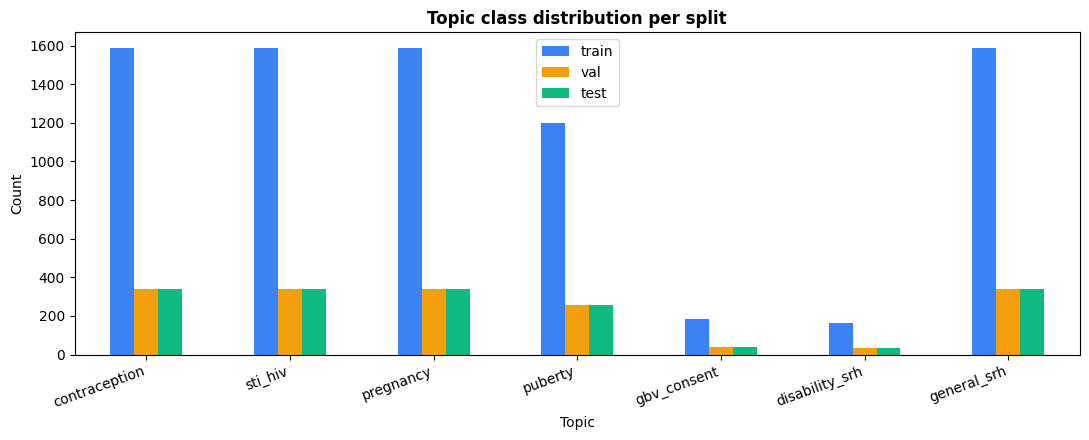

In [4]:
# ── Leakage guard (must stay zero even after augmentation) ──
def _keys(df): return set(df['text'].str.strip().str.lower())
ktr, kva, kte = _keys(train_df), _keys(val_df), _keys(test_df)
print(f'Leakage check  train&val={len(ktr & kva)}  train&test={len(ktr & kte)}'
      f'  val&test={len(kva & kte)}')
assert not (ktr & kva) and not (ktr & kte) and not (kva & kte), 'LEAKAGE DETECTED'

dist = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'val':   val_df['label'].value_counts().sort_index(),
    'test':  test_df['label'].value_counts().sort_index(),
}).fillna(0).astype(int)
dist.index = [INT_TO_TOPIC[i] for i in dist.index]
print('\nClass distribution per split:')
print(dist.to_string())

ax = dist.plot(kind='bar', figsize=(11, 4.5), color=['#3B82F6', '#F59E0B', '#10B981'])
ax.set_title('Topic class distribution per split', fontweight='bold')
ax.set_xlabel('Topic'); ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_topic_class_distribution_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

X_train, y_train = train_df['text'], train_df['label'].values
X_val,   y_val   = val_df['text'],   val_df['label'].values
X_test,  y_test  = test_df['text'],  test_df['label'].values
N_CLASSES = len(CLASS_NAMES)

---
## STEP 3 — Feature extraction: TF-IDF (fit on train only)

In [5]:
TFIDF_PARAMS = dict(
    ngram_range   = (1, 2),
    max_features  = 30_000,
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'\b[a-zA-Z][a-zA-Z0-9]{1,}\b',
)

def make_pipeline(classifier):
    return Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', classifier)])

print('TF-IDF configured (ngram 1-2, max 30k features, fit on train only).')

TF-IDF configured (ngram 1-2, max 30k features, fit on train only).


---
## STEP 4 — Define the three models

In [6]:
lr_pipeline = make_pipeline(
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs',
                       multi_class='multinomial', class_weight='balanced',
                       random_state=RANDOM_SEED))
svm_pipeline = make_pipeline(
    CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=5000, class_weight='balanced',
                  random_state=RANDOM_SEED), cv=3))
xgb_pipeline = make_pipeline(
    XGBClassifier(objective='multi:softprob', num_class=7, n_estimators=300,
                  max_depth=6, learning_rate=0.1, subsample=0.8,
                  colsample_bytree=0.8, eval_metric='mlogloss', tree_method='hist',
                  random_state=RANDOM_SEED, n_jobs=-1))
MODELS = {'Logistic Regression': lr_pipeline, 'Linear SVM': svm_pipeline,
          'XGBoost': xgb_pipeline}
print('Models defined:'); [print(f'  - {n}') for n in MODELS]

Models defined:
  - Logistic Regression
  - Linear SVM
  - XGBoost


[None, None, None]

---
## STEP 5 — Train & evaluate on the VALIDATION set
Test set untouched until Step 7.

In [7]:
y_val_bin = label_binarize(y_val, classes=list(range(N_CLASSES)))
results = {}
for name, pipeline in MODELS.items():
    print('\n' + '=' * 60); print(f'  Training: {name}'); print('=' * 60)
    fit_params = {}
    if name == 'XGBoost':
        fit_params['clf__sample_weight'] = compute_sample_weight('balanced', y_train)
    t0 = time.time(); pipeline.fit(X_train, y_train, **fit_params)
    train_time = time.time() - t0
    y_pred = pipeline.predict(X_val); y_prob = pipeline.predict_proba(X_val)
    acc         = accuracy_score(y_val, y_pred)
    f1_macro    = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    per_class   = f1_score(y_val, y_pred, average=None)
    roc_auc     = roc_auc_score(y_val_bin, y_prob, multi_class='ovr', average='macro')
    results[name] = {
        'accuracy': round(acc, 4), 'f1_macro': round(f1_macro, 4),
        'f1_weighted': round(f1_weighted, 4), 'roc_auc_ovr': round(roc_auc, 4),
        'train_sec': round(train_time, 1),
        'per_class_f1': {CLASS_NAMES[i]: round(float(per_class[i]), 4)
                         for i in range(N_CLASSES)}, 'pipeline': pipeline}
    print(f'  Train time   : {train_time:.1f}s')
    print(f'  Accuracy     : {acc:.4f}')
    print(f'  F1 Macro     : {f1_macro:.4f}   <- selection metric')
    print(f'  F1 Weighted  : {f1_weighted:.4f}')
    print(f'  ROC-AUC (ovr): {roc_auc:.4f}')
    print('  Per-class F1 :', {CLASS_NAMES[i]: round(float(per_class[i]),3) for i in range(N_CLASSES)})
    print('\n  Classification report (val):')
    print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, zero_division=0))
print('\nAll models trained.')


  Training: Logistic Regression


  Train time   : 25.5s
  Accuracy     : 0.8842
  F1 Macro     : 0.9006   <- selection metric
  F1 Weighted  : 0.8852
  ROC-AUC (ovr): 0.9891
  Per-class F1 : {'contraception': 0.899, 'sti_hiv': 0.908, 'pregnancy': 0.877, 'puberty': 0.849, 'gbv_consent': 0.946, 'disability_srh': 0.955, 'general_srh': 0.87}

  Classification report (val):
                precision    recall  f1-score   support

 contraception       0.94      0.87      0.90       341
       sti_hiv       0.95      0.87      0.91       341
     pregnancy       0.91      0.85      0.88       340
       puberty       0.80      0.91      0.85       256
   gbv_consent       1.00      0.90      0.95        39
disability_srh       1.00      0.91      0.96        35
   general_srh       0.82      0.93      0.87       341

      accuracy                           0.88      1693
     macro avg       0.92      0.89      0.90      1693
  weighted avg       0.89      0.88      0.89      1693


  Training: Linear SVM


  Train time   : 11.9s
  Accuracy     : 0.9203
  F1 Macro     : 0.9249   <- selection metric
  F1 Weighted  : 0.9205
  ROC-AUC (ovr): 0.9942
  Per-class F1 : {'contraception': 0.935, 'sti_hiv': 0.944, 'pregnancy': 0.908, 'puberty': 0.891, 'gbv_consent': 0.961, 'disability_srh': 0.923, 'general_srh': 0.914}

  Classification report (val):
                precision    recall  f1-score   support

 contraception       0.95      0.92      0.93       341
       sti_hiv       0.95      0.93      0.94       341
     pregnancy       0.92      0.90      0.91       340
       puberty       0.86      0.93      0.89       256
   gbv_consent       0.97      0.95      0.96        39
disability_srh       1.00      0.86      0.92        35
   general_srh       0.90      0.93      0.91       341

      accuracy                           0.92      1693
     macro avg       0.94      0.92      0.92      1693
  weighted avg       0.92      0.92      0.92      1693


  Training: XGBoost


  Train time   : 567.0s
  Accuracy     : 0.9663
  F1 Macro     : 0.9638   <- selection metric
  F1 Weighted  : 0.9663
  ROC-AUC (ovr): 0.9980
  Per-class F1 : {'contraception': 0.975, 'sti_hiv': 0.978, 'pregnancy': 0.956, 'puberty': 0.964, 'gbv_consent': 0.974, 'disability_srh': 0.939, 'general_srh': 0.96}

  Classification report (val):
                precision    recall  f1-score   support

 contraception       0.99      0.96      0.97       341
       sti_hiv       0.98      0.98      0.98       341
     pregnancy       0.95      0.96      0.96       340
       puberty       0.95      0.98      0.96       256
   gbv_consent       0.97      0.97      0.97        39
disability_srh       1.00      0.89      0.94        35
   general_srh       0.96      0.96      0.96       341

      accuracy                           0.97      1693
     macro avg       0.97      0.96      0.96      1693
  weighted avg       0.97      0.97      0.97      1693


All models trained.


---
## STEP 6 — Model comparison & selection (by F1 macro)

Model comparison (sorted by F1 Macro):
              Model  Accuracy  F1 Macro  F1 Weighted  ROC-AUC  Train (s)
            XGBoost    0.9663    0.9638       0.9663   0.9980      567.0
         Linear SVM    0.9203    0.9249       0.9205   0.9942       11.9
Logistic Regression    0.8842    0.9006       0.8852   0.9891       25.5

Best model by F1 Macro: XGBoost  (F1 Macro = 0.9638)


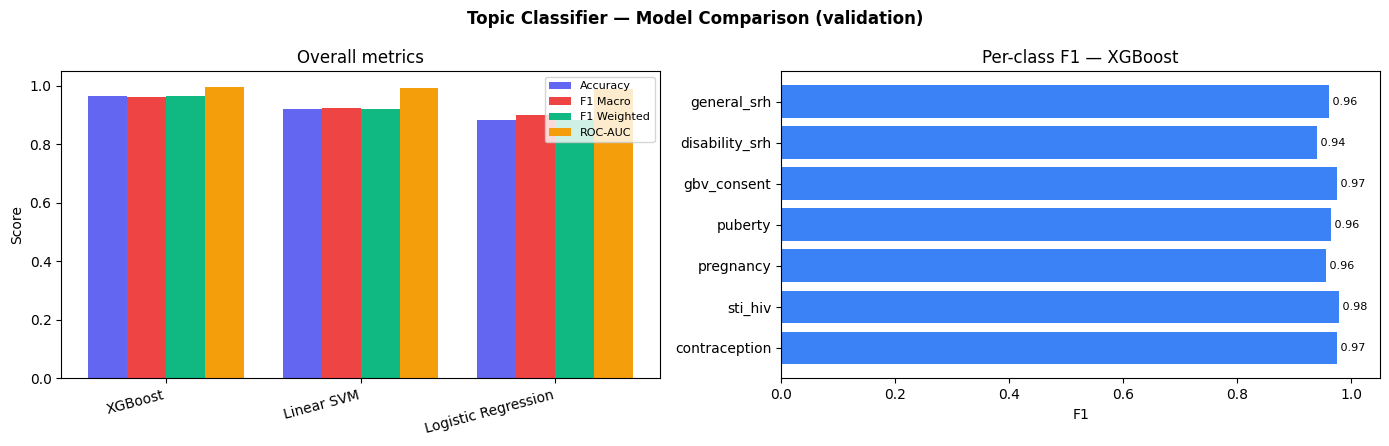

Saved: models/fig_topic_model_comparison_B.png


In [8]:
rows = [{'Model': n, 'Accuracy': r['accuracy'], 'F1 Macro': r['f1_macro'],
         'F1 Weighted': r['f1_weighted'], 'ROC-AUC': r['roc_auc_ovr'],
         'Train (s)': r['train_sec']} for n, r in results.items()]
comparison = pd.DataFrame(rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print('Model comparison (sorted by F1 Macro):'); print(comparison.to_string(index=False))
best_name = comparison.iloc[0]['Model']; best_pipeline = results[best_name]['pipeline']
print(f'\nBest model by F1 Macro: {best_name}  (F1 Macro = {results[best_name]["f1_macro"]})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Topic Classifier — Model Comparison (validation)', fontsize=12, fontweight='bold')
models = comparison['Model'].tolist(); x = np.arange(len(models)); w = 0.2
axes[0].bar(x-1.5*w, comparison['Accuracy'],    width=w, label='Accuracy',    color='#6366F1')
axes[0].bar(x-0.5*w, comparison['F1 Macro'],    width=w, label='F1 Macro',    color='#EF4444')
axes[0].bar(x+0.5*w, comparison['F1 Weighted'], width=w, label='F1 Weighted', color='#10B981')
axes[0].bar(x+1.5*w, comparison['ROC-AUC'],     width=w, label='ROC-AUC',     color='#F59E0B')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Score'); axes[0].set_title('Overall metrics')
axes[0].legend(fontsize=8)
pcf = results[best_name]['per_class_f1']
axes[1].barh(list(pcf.keys()), list(pcf.values()), color='#3B82F6')
axes[1].set_xlim(0, 1.05); axes[1].set_title(f'Per-class F1 — {best_name}'); axes[1].set_xlabel('F1')
for i, v in enumerate(pcf.values()): axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_topic_model_comparison_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show(); print(f'Saved: {MODEL_DIR}/fig_topic_model_comparison_{TAG}.png')

---
## STEP 7 — Evaluate the best model on the held-out TEST set
⚠️ **Run once.**

TEST SET RESULTS — XGBoost
  Accuracy     : 0.9693
  F1 Macro     : 0.9628
  F1 Weighted  : 0.9692
  ROC-AUC (ovr): 0.9985

                precision    recall  f1-score   support

 contraception       0.96      0.99      0.97       340
       sti_hiv       0.98      0.97      0.97       340
     pregnancy       0.96      0.96      0.96       341
       puberty       0.97      0.98      0.97       257
   gbv_consent       0.97      0.95      0.96        40
disability_srh       1.00      0.86      0.93        36
   general_srh       0.98      0.97      0.97       340

      accuracy                           0.97      1694
     macro avg       0.97      0.95      0.96      1694
  weighted avg       0.97      0.97      0.97      1694



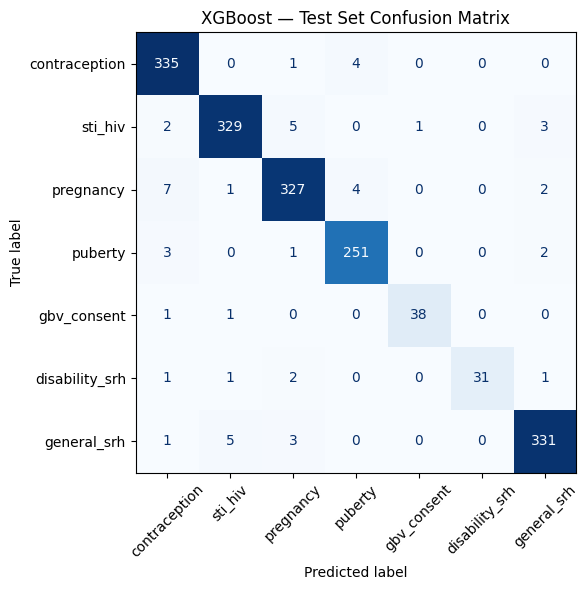

Saved: models/fig_topic_confusion_matrix_B.png


In [9]:
y_pred_test = best_pipeline.predict(X_test); y_prob_test = best_pipeline.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
test_acc      = accuracy_score(y_test, y_pred_test)
test_f1_macro = f1_score(y_test, y_pred_test, average='macro')
test_f1_wtd   = f1_score(y_test, y_pred_test, average='weighted')
test_auc      = roc_auc_score(y_test_bin, y_prob_test, multi_class='ovr', average='macro')
print(f'TEST SET RESULTS — {best_name}')
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  F1 Macro     : {test_f1_macro:.4f}')
print(f'  F1 Weighted  : {test_f1_wtd:.4f}')
print(f'  ROC-AUC (ovr): {test_auc:.4f}\n')
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=CLASS_NAMES,
    xticks_rotation=45, colorbar=False, cmap='Blues', ax=ax)
ax.set_title(f'{best_name} — Test Set Confusion Matrix'); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_topic_confusion_matrix_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show(); print(f'Saved: {MODEL_DIR}/fig_topic_confusion_matrix_{TAG}.png')

---
## STEP 8 — Save the winning pipeline + metadata

In [10]:
joblib.dump(best_pipeline, f'{MODEL_DIR}/topic_classifier_{TAG}.pkl')
meta = {'model': 'Model 3 — SRH Intent & Topic Classifier', 'approach': APPROACH,
        'best_model': best_name, 'classes': CLASS_NAMES,
        'features': 'TF-IDF (word, ngram 1-2, max 30k, sublinear)',
        'val_metrics': {k: results[best_name][k] for k in
                        ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc_ovr']},
        'val_per_class_f1': results[best_name]['per_class_f1'],
        'test_metrics': {'accuracy': round(test_acc, 4), 'f1_macro': round(test_f1_macro, 4),
                         'f1_weighted': round(test_f1_wtd, 4), 'roc_auc_ovr': round(test_auc, 4)},
        'rows': {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}}
with open(f'{MODEL_DIR}/topic_classifier_{TAG}_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved: {MODEL_DIR}/topic_classifier_{TAG}.pkl')
print(f'Saved: {MODEL_DIR}/topic_classifier_{TAG}_metadata.json')
print(json.dumps(meta, indent=2))

Saved: models/topic_classifier_B.pkl
Saved: models/topic_classifier_B_metadata.json
{
  "model": "Model 3 \u2014 SRH Intent & Topic Classifier",
  "approach": "Approach B \u2014 Augmented Minority",
  "best_model": "XGBoost",
  "classes": [
    "contraception",
    "sti_hiv",
    "pregnancy",
    "puberty",
    "gbv_consent",
    "disability_srh",
    "general_srh"
  ],
  "features": "TF-IDF (word, ngram 1-2, max 30k, sublinear)",
  "val_metrics": {
    "accuracy": 0.9663,
    "f1_macro": 0.9638,
    "f1_weighted": 0.9663,
    "roc_auc_ovr": 0.998
  },
  "val_per_class_f1": {
    "contraception": 0.9748,
    "sti_hiv": 0.978,
    "pregnancy": 0.9561,
    "puberty": 0.9635,
    "gbv_consent": 0.9744,
    "disability_srh": 0.9394,
    "general_srh": 0.9602
  },
  "test_metrics": {
    "accuracy": 0.9693,
    "f1_macro": 0.9628,
    "f1_weighted": 0.9692,
    "roc_auc_ovr": 0.9985
  },
  "rows": {
    "train": 7902,
    "val": 1693,
    "test": 1694
  }
}


---
## STEP 9 — Quick inference sanity check

In [11]:
loaded = joblib.load(f'{MODEL_DIR}/topic_classifier_{TAG}.pkl')
samples = [
    'Where can I get free condoms and birth control pills in Kigali?',
    'I think I was exposed to HIV, where can I get tested and start PrEP?',
    'I missed my period and the pregnancy test is positive, what now?',
    'My 13 year old daughter just started menstruating, is this normal puberty?',
    'Someone forced me to have sex without my consent, where can I report it?',
    'Can a person who uses a wheelchair safely use contraception?',
    'What is the difference between sex and gender in reproductive health?',
]
preds = loaded.predict(pd.Series(samples))
print(f'{"Predicted topic":<16}  Query'); print('-' * 90)
for q, p in zip(samples, preds): print(f'{INT_TO_TOPIC[int(p)]:<16}  {q[:70]}')

Predicted topic   Query
------------------------------------------------------------------------------------------
contraception     Where can I get free condoms and birth control pills in Kigali?
sti_hiv           I think I was exposed to HIV, where can I get tested and start PrEP?
puberty           I missed my period and the pregnancy test is positive, what now?
puberty           My 13 year old daughter just started menstruating, is this normal pube
gbv_consent       Someone forced me to have sex without my consent, where can I report i
contraception     Can a person who uses a wheelchair safely use contraception?
gbv_consent       What is the difference between sex and gender in reproductive health?


---
## STEP 10 — Summary & caveats

**How to read these results (Approach B):**
- The two rare classes are now trainable (~220 rows each), so the model can actually
  **recognise GBV/consent and disability-SRH queries** — important for this platform's
  users.
- **But their val/test F1 is optimistic**: the authored questions are clean and
  templated, so they are easier than real messy questions. Treat rare-class scores here
  as an *upper bound*, and use **Approach A** for the honest data-reality estimate.
- Everything else (features, models, selection by F1 macro, evaluation protocol) is
  identical to Approach A, so the two notebooks are directly comparable.
- Next real step would be to **collect/annotate genuine GBV and disability-SRH data** to
  replace the authored bank.

In [12]:
print('=' * 68)
print(f'TOPIC CLASSIFIER (Model 3) — {APPROACH} — COMPLETE')
print('=' * 68)
print(f'  Winning model : {best_name}  (selected by F1 macro)')
print(f'  Rows          : train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')
print('\n  Validation comparison:'); print(comparison.to_string(index=False))
print('\n  Held-out TEST metrics:')
print(f'    Accuracy     : {test_acc:.4f}')
print(f'    F1 Macro     : {test_f1_macro:.4f}')
print(f'    F1 Weighted  : {test_f1_wtd:.4f}')
print(f'    ROC-AUC (ovr): {test_auc:.4f}')
pcf_test = f1_score(y_test, y_pred_test, average=None)
order = sorted(range(N_CLASSES), key=lambda i: pcf_test[i])
print('\n  Weakest classes  :', ', '.join(f'{CLASS_NAMES[i]} ({pcf_test[i]:.2f})' for i in order[:2]))
print('  Strongest classes:', ', '.join(f'{CLASS_NAMES[i]} ({pcf_test[i]:.2f})' for i in order[-2:]))
print()
print('  Approach B caveats:')
print('   - gbv_consent / disability_srh bolstered with ~220 authored rows each')
print('     (source=authored_bank). Rare-class test F1 is OPTIMISTIC (templated text).')
print('   - Use Approach A for the honest data-reality estimate.')
print('   - Next step: collect real GBV / disability-SRH data to replace the bank.')
print('=' * 68)

TOPIC CLASSIFIER (Model 3) — Approach B — Augmented Minority — COMPLETE
  Winning model : XGBoost  (selected by F1 macro)
  Rows          : train=7,902  val=1,693  test=1,694

  Validation comparison:
              Model  Accuracy  F1 Macro  F1 Weighted  ROC-AUC  Train (s)
            XGBoost    0.9663    0.9638       0.9663   0.9980      567.0
         Linear SVM    0.9203    0.9249       0.9205   0.9942       11.9
Logistic Regression    0.8842    0.9006       0.8852   0.9891       25.5

  Held-out TEST metrics:
    Accuracy     : 0.9693
    F1 Macro     : 0.9628
    F1 Weighted  : 0.9692
    ROC-AUC (ovr): 0.9985

  Weakest classes  : disability_srh (0.93), pregnancy (0.96)
  Strongest classes: puberty (0.97), general_srh (0.97)

  Approach B caveats:
   - gbv_consent / disability_srh bolstered with ~220 authored rows each
     (source=authored_bank). Rare-class test F1 is OPTIMISTIC (templated text).
   - Use Approach A for the honest data-reality estimate.
   - Next step: collect r